# Store Performance Report — Assignment

## NumPy & Pandas Mini-Project

---

**Scenario:**

> The manager has handed you last year's order data and asked you to prepare a short report answering a set of business questions. Use **NumPy** and **Pandas** — no manual counting allowed!

**Dataset:** Sample Superstore (`superstore.csv`)

**Deliverable:** This completed notebook — code cells filled in + short markdown explanations where asked.

**Rules:**
- Every answer must be computed with code, not typed manually.
- Where it says **"Write your answer"**, add a markdown cell explaining what you found in 2–3 sentences.
- You may add extra cells if needed.

---

## Setup

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots show inline
%matplotlib inline

# Optional: make plots a bit nicer
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

---

## Part 1 — Data Overview (10 pts)

Load the dataset and get familiar with its structure. This is always the first step in any analysis.

### 1.1 Load the data

In [ ]:
df = pd.read_csv('Superstore.csv', encoding='latin-1')
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


### 1.2 How many rows and columns does the dataset have?

In [ ]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")



Rows: 9994
Columns: 21


### 1.3 Display the first 5 rows

In [ ]:

df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 1.4 Inspect column types and check for missing values

In [ ]:
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

--- Missing Values ---
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


### 1.5 Show summary statistics for the numeric columns

In [ ]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### 1.6 What date range does the data cover?

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(f"Earliest order: {df['Order Date'].min()}")
print(f"Latest order:   {df['Order Date'].max()}")


Earliest order: 2014-01-03 00:00:00
Latest order:   2017-12-30 00:00:00


> **Write your answer:** What did you learn about this dataset from your exploration? (size, types of columns, any missing data, date range)

This dataset has 9,994 rows and 21 columns, with orders recorded from January 3, 2014 to December 30, 2017. The columns cover order details, customer information such as segment and region, product details like category and sub-category, and financial metrics including sales, quantity, discount, and profit. All columns are complete with no missing values.

---

## Part 2 — Sales Analysis (20 pts)

Let's dig into the revenue and profit numbers.

### 2.1 What is the total revenue (Sales) and total profit across the entire dataset?

In [ ]:
# Calculate total Sales and total Profit

tot_sales = df['Sales'].sum()
tot_profit = df['Profit'].sum()

print(f"Total Revenue (Sales): ${tot_sales}")
print(f"Total Profit:          ${tot_profit}")


Total Revenue (Sales): $2297200.8603
Total Profit:          $286397.0217


### 2.2 Which Category generates the most revenue? Which generates the most profit?

In [ ]:
# Group by 'Category', sum Sales and Profit
cat_tot = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print(cat_tot)

print(f"Highest revenue category: {cat_tot['Sales'].idxmax()}")
print(f"Highest profit category:  {cat_tot['Profit'].idxmax()}")


                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Highest revenue category: Technology
Highest profit category:  Technology


> **Write your answer:** Are the highest-revenue and highest-profit categories the same? What does that tell you?

Technology generates the most revenue and also the most profit. Furniture ranks second in revenue but last in profit, meaning it has very thin margins. This tells us that high sales volume does not guarantee high profitability.

### 2.3 Top 10 Sub-Categories by total Sales — show as a horizontal bar chart

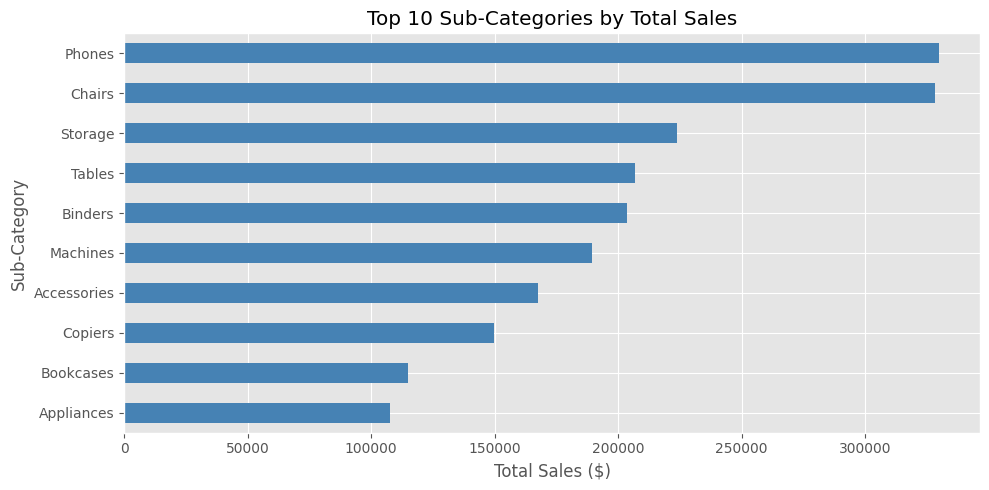

In [ ]:
top = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)

top.plot(kind='barh', color='steelblue')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')
plt.title('Top 10 Sub-Categories by Total Sales')
plt.tight_layout()
plt.show()

### 2.4 Bottom 5 Sub-Categories by total Profit — are any losing money?

In [ ]:
bottom5 = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(5)
print(bottom5)

print(f"\nSub-Categories losing money: {list(bottom5[bottom5 < 0].index)}")

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

Sub-Categories losing money: ['Tables', 'Bookcases', 'Supplies']


> **Write your answer:** Which Sub-Categories are losing money? Why do you think that might be happening?

The three subcategories that are losing money are Supplies, Bookcases, and Tables. By far, tables have suffered the greatest loss. This is probably due to the furniture category's steep discounts and high product costs, which make shipping and storing these items costly.

---

## Part 3 — Regional Breakdown (15 pts)

Compare how the four regions (East, West, Central, South) are performing.

### 3.1 For each region, calculate: total Sales, total Profit, and average Profit Margin

In [ ]:
region = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
)
region['Avg_Profit_Margin (%)'] = (region['Profit'] / region['Sales']) * 100

print(region.round(2))

             Sales     Profit  Avg_Profit_Margin (%)
Region                                              
Central  501239.89   39706.36                   7.92
East     678781.24   91522.78                  13.48
South    391721.90   46749.43                  11.93
West     725457.82  108418.45                  14.94


### 3.2 Which region has the highest average discount?

In [ ]:
avg = df.groupby('Region')['Discount'].mean().sort_values(ascending=False)
print(avg)

print(f"\nHighest average discount region: {avg.idxmax()}")


Region
Central    0.240353
South      0.147253
East       0.145365
West       0.109335
Name: Discount, dtype: float64

Highest average discount region: Central


> **Write your answer:** Does the region with the highest average discount also have lower profit? What does this suggest about the company's discounting strategy?

In addition to having the lowest profit margin (8%), the Central region has the largest average discount (24%). The West, on the other hand, has the biggest profit margin (15%) and the lowest average discount (11%). This implies that the corporation should reevaluate its discounting approach in the Central region because aggressive discounting there is affecting profits.

---

## Part 4 — Customer Segments (15 pts)

The data has three customer segments: Consumer, Corporate, and Home Office.

### 4.1 How many orders does each segment have?

In [ ]:
segment = df.groupby('Segment')['Order ID'].count()
print(segment)


Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: Order ID, dtype: int64


### 4.2 Compare segments by average order value (Sales) and average Profit

In [ ]:
segment_avg = df.groupby('Segment')[['Sales', 'Profit']].mean()
print(segment_avg.round(2))


              Sales  Profit
Segment                    
Consumer     223.73   25.84
Corporate    233.82   30.46
Home Office  240.97   33.82


### 4.3 Which segment is most profitable per order?

In [ ]:
profitable = segment_avg['Profit'].idxmax()
print(f"Most profitable segment per order: {profitable}")


Most profitable segment per order: Home Office


> **Write your answer:** If you were the store manager, which segment would you focus marketing efforts on and why?

Home Office is the most profitable segment per order (~$33.82 avg profit), despite having the fewest total orders (1,783). As a store manager, I would focus marketing efforts on the Home Office segment — it has the highest average order value and best profit per order. Targeted campaigns (e.g., bulk office supply bundles) could grow this high-value but under-served segment.

---

## Part 5 — The Discount Problem (20 pts)

This is the most interesting part. Let's investigate how discounts affect profitability.

### 5.1 Create a new column: `Discount_Level`

| Discount value | Label |
|---|---|
| 0 | "No Discount" |
| > 0 and <= 0.2 | "Low" |
| > 0.2 | "High" |

Hint: You can use `np.select()` or `pd.cut()` or a series of conditions.

In [ ]:
# Create the Discount_Level column
# YOUR CODE HERE
conditions = [
    df['Discount'] == 0,
    (df['Discount'] > 0) & (df['Discount'] <= 0.2),
    df['Discount'] > 0.2
]
choices = ['No Discount', 'Low', 'High']

df['Discount_Level'] = np.select(conditions, choices, default='Other')

print(df['Discount_Level'].value_counts())

Discount_Level
No Discount    4798
Low            3803
High           1393
Name: count, dtype: int64


### 5.2 Group by Discount_Level — calculate average Sales, average Profit, and count

In [ ]:
# YOUR CODE HERE
discount = df.groupby('Discount_Level').agg(
    Avg_Sales=('Sales', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Count=('Sales', 'count')
)
print(discount)

                 Avg_Sales  Avg_Profit  Count
Discount_Level                               
High            260.423654  -97.183098   1393
Low             222.593279   26.501571   3803
No Discount     226.742074   66.900292   4798


### 5.3 Visualize: bar chart of average Profit by Discount Level

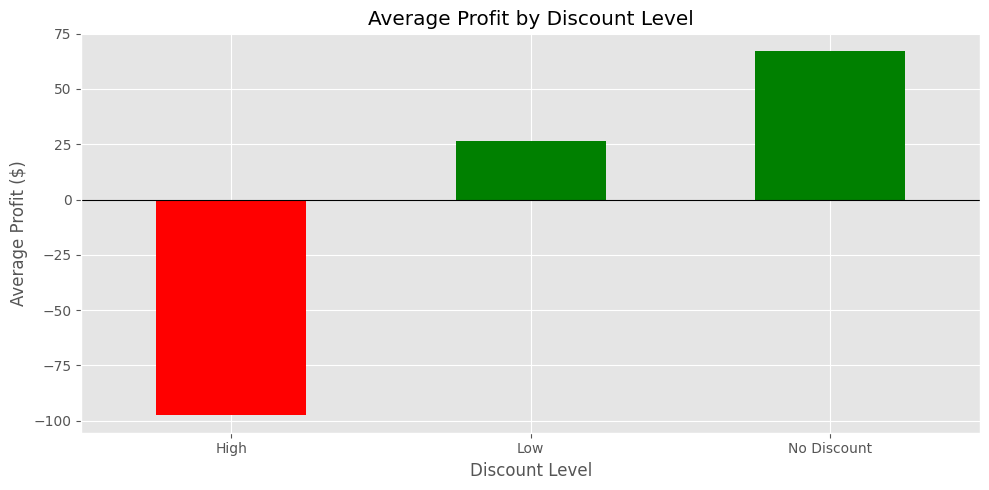

In [ ]:
# Plot the average Profit for each Discount_Level as a bar chart
# YOUR CODE HERE
avg_profit = df.groupby('Discount_Level')['Profit'].mean()

colors = ['green' if v >= 0 else 'red' for v in avg_profit.values]
avg_profit.plot(kind='bar', color=colors)
plt.ylabel('Average Profit ($)')
plt.xlabel('Discount Level')
plt.title('Average Profit by Discount Level')
plt.xticks(rotation=0)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

> **Write your answer:** What happens to profit as discounts increase? Why do you think this is? Write 2–3 sentences explaining what you found.

As discount levels rise, profit clearly declines. Orders without discounts yield the highest average profit at $67, while low-discount orders generate a modest profit of $27, but high-discount orders result in an average loss of $97. This indicates that discounts exceeding 20% are undermining profitability and should be utilized only minimally or discontinued.

---

## Part 6 — NumPy Connection (15 pts)

Here you'll bridge NumPy and Pandas to show they work together.

### 6.1 Extract the Sales column as a NumPy array

In [ ]:
# Use .to_numpy() to extract Sales as a NumPy array
arr = df['Sales'].to_numpy()

# Verify it's a numpy array
print(type(arr))
print(f"Shape: {arr.shape}")

<class 'numpy.ndarray'>
Shape: (9994,)


### 6.2 Calculate mean and standard deviation using NumPy

In [ ]:
mean = np.mean(arr)
std = np.std(arr)

print(f"Mean Sales:  ${mean:.2f}")
print(f"Std Dev:     ${std:.2f}")


Mean Sales:  $229.86
Std Dev:     $623.21


### 6.3 Calculate the z-score for each sale

In [ ]:
z_scores = (arr - mean) / std

print(f"First 10 z-scores: {z_scores[:10].round(2)}")


First 10 z-scores: [ 0.05  0.81 -0.35  1.17 -0.33 -0.29 -0.36  1.09 -0.34 -0.18]


### 6.4 Find outliers (z-score > 2) and add as a new column

In [ ]:
df['Is_Outlier'] = z_scores > 2

print(f"Number of outlier orders: {df['Is_Outlier'].sum()}")
print(f"Percentage of total: {df['Is_Outlier'].mean() * 100:.2f}%")
df.head()


Number of outlier orders: 247
Percentage of total: 2.47%


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Discount_Level,Is_Outlier
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,No Discount,False
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,No Discount,False
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,No Discount,False
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,High,False
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Low,False


### 6.5 What categories do these outlier (unusually large) orders belong to?

In [ ]:
outlier = df[df['Is_Outlier']]['Category'].value_counts()
print(outlier)

Category
Technology         99
Furniture          83
Office Supplies    65
Name: count, dtype: int64


> **Write your answer:** What categories do the unusually large orders tend to be in? Does this make sense?

The unusually large orders are dominated by Technology, followed by Furniture and then Office Supplies. This is logical because technology products and furniture items typically carry significantly higher unit prices, which means individual orders in these categories are more likely to generate substantially higher sales volumes.

---

## Summary

> **Write your final summary here:** In 4–5 sentences, describe the most interesting things you found in this dataset. What would you recommend to the store manager based on your analysis?

The total sales and net income made by the store within the period of 2014-2017 were about $2.3 million and $286 thousand, respectively. Technology appears to be the key product line in terms of both revenues and profits. Meanwhile, the Furniture line brings significant sales but low margins since Tables and Bookcases segments suffer from losses. The Central zone performs poorly in terms of sales, being characterized by the highest level of discounts and lowest profit margins, implying that over-discounting is a major issue for this zone. Orders with discounts higher than 20% prove unprofitable, making the company drastically reduce their number. Lastly, the Home Office sector is the most lucrative one.

---

### Submission Checklist

- [ ] All code cells run without errors (Kernel → Restart & Run All)
- [ ] All "Write your answer" sections are filled in
- [ ] Charts have readable labels
- [ ] No hardcoded answers — everything is computed with code

**Good luck!**